##Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

##Step 2:  Load the Dataset

In [ ]:
from google.colab import files
# Upload the dataset from your local computer
files.upload()
# Read the dataset into a Pandas DataFrame
df = pd.read_csv('household_power_consumption.txt', delimiter=';')
# Display the dataset dimensions (rows, columns)
print(df.shape) #2,075,259 (Rows) 9 (Columns)

Saving household_power_consumption.txt to household_power_consumption.txt
(2075259, 9)


/tmp/ipykernel_1469/3065752990.py:5: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('household_power_consumption.txt', delimiter=';')


##Step 3: Explore the Dataset

In [ ]:

# Display the first 10 rows
df.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
5,16/12/2006,17:29:00,3.520,0.522,235.020,15.000,0.000,2.000,17.0
6,16/12/2006,17:30:00,3.702,0.520,235.090,15.800,0.000,1.000,17.0
7,16/12/2006,17:31:00,3.700,0.520,235.220,15.800,0.000,1.000,17.0
8,16/12/2006,17:32:00,3.668,0.510,233.990,15.800,0.000,1.000,17.0
9,16/12/2006,17:33:00,3.662,0.510,233.860,15.800,0.000,2.000,16.0


In [ ]:
# Display information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [ ]:
# Display statistical summary of numerical columns
df.describe()

,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [ ]:
# Display the names of all columns
print(df.columns)

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


##Step 4: Check Missing Values


In [ ]:
# Count missing values in each column
print(df.isnull().sum())

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64


##Step 5: Data Cleaning

In [ ]:
# Remove rows containing '?' values in the target-related column
df = df[df['Global_active_power'] != "?"]

# Define columns that should be converted to numerical format
numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3']
# Convert columns from object type to numeric type
# Invalid values will be converted into NaN
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Remove rows containing missing values after conversion
df = df.dropna()

# Create a new feature representing the total sub-metering consumption
df['meter'] = (
    df['Sub_metering_1'] +
    df['Sub_metering_2'] +
    df['Sub_metering_3']
)

In [ ]:
# Check the dataset information after cleaning
df.info()

# Check the new dataset size
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
 9   meter                  float64
dtypes: float64(8), object(2)
memory usage: 172.0+ MB
(2049280, 10)


In [ ]:
df.isnull().sum() #chek again

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
meter,0


##Step 6: Feature Engineering (Date & Time)

In [ ]:
#I notice that Date = 16/12/2006 , Time = 17:24:00
# Convert the Date column from string format to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Convert the Time column from string format to datetime format
time = pd.to_datetime(df['Time'])
# Extract hour from Time 17:24:00 --> 17
df['hour'] = time.dt.hour
# Extract minute from Time 17:24:00 --> 24
df['minute'] = time.dt.minute
# Extract the day of the week  Monday = 0, Sunday = 6
df['weekday'] = df['Date'].dt.weekday
# Extract day of the month  16/12/2006 --> 16
df['day'] = df['Date'].dt.day
# Extract month 16/12/2006 --> 12
df['month'] = df['Date'].dt.month
# Extract year 16/12/2006 --> 2006
df['year'] = df['Date'].dt.year


/tmp/ipykernel_1469/4079534592.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time = pd.to_datetime(df['Time'])


In [ ]:
# Display the new features
df[['Date','Time','hour','minute','weekday','day','month','year']].head()

,Date,Time,hour,minute,weekday,day,month,year
0,2006-12-16,17:24:00,17,24,5,16,12,2006
1,2006-12-16,17:25:00,17,25,5,16,12,2006
2,2006-12-16,17:26:00,17,26,5,16,12,2006
3,2006-12-16,17:27:00,17,27,5,16,12,2006
4,2006-12-16,17:28:00,17,28,5,16,12,2006


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   datetime64[ns]
 1   Time                   object        
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   meter                  float64       
 10  hour                   int32         
 11  minute                 int32         
 12  weekday                int32         
 13  day                    int32         
 14  month                  int32         
 15  year                   int32         
dtypes: datetime64[ns](1), float64(8), int32(6), object(1)
memory usage: 218.9+ MB


##Step 7: Data Visualization

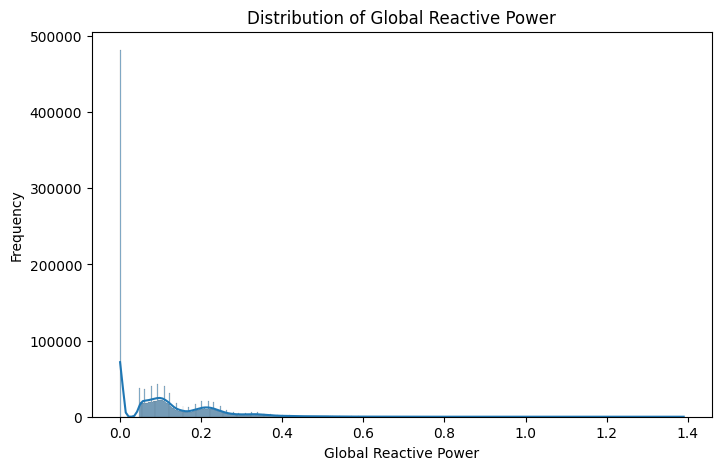

In [ ]:
#Q1: What is the distribution of Global Reactive Power values?
plt.figure(figsize=(8,5))

sns.histplot(df['Global_reactive_power'], kde=True)

plt.title("Distribution of Global Reactive Power")
plt.xlabel("Global Reactive Power")
plt.ylabel("Frequency")

plt.show()

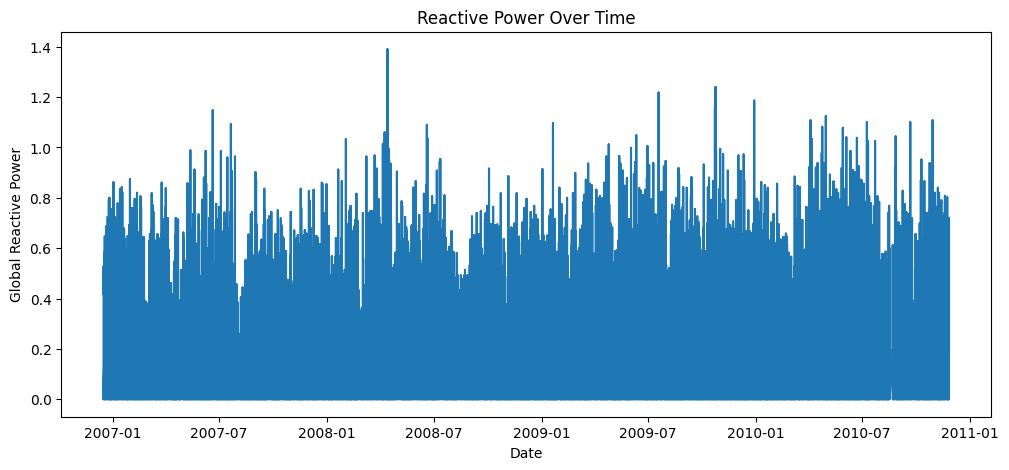

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Global_reactive_power']
)

plt.title("Reactive Power Over Time")
plt.xlabel("Date")
plt.ylabel("Global Reactive Power")

plt.show()

##Step 8:Train/Test Split

In [ ]:
#Define X and y
y=df['Global_reactive_power'] # Target
x=df.drop(columns=["Global_reactive_power","Date","Time"])#Features

In [ ]:
x.shape

(2049280, 13)

In [ ]:
y.shape

(2049280,)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42 ## Ensures the same split every time we run the code
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1639424, 13)
(409856, 13)
(1639424,)
(409856,)


## Step 10: Train Models with  LinearRegression


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
# Train the model using the training data
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


##Step 11: Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Lower MAE means the predictions are closer to the real values
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# It calculates the average of squared differences between actual and predicted values
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

# R2 shows how much variation in the target variable is explained by the model
# Value closer to 1 means better prediction performance
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MAE: 0.07430322862652528
RMSE: 0.09704504701759126
R2 Score: 0.2581192106756609


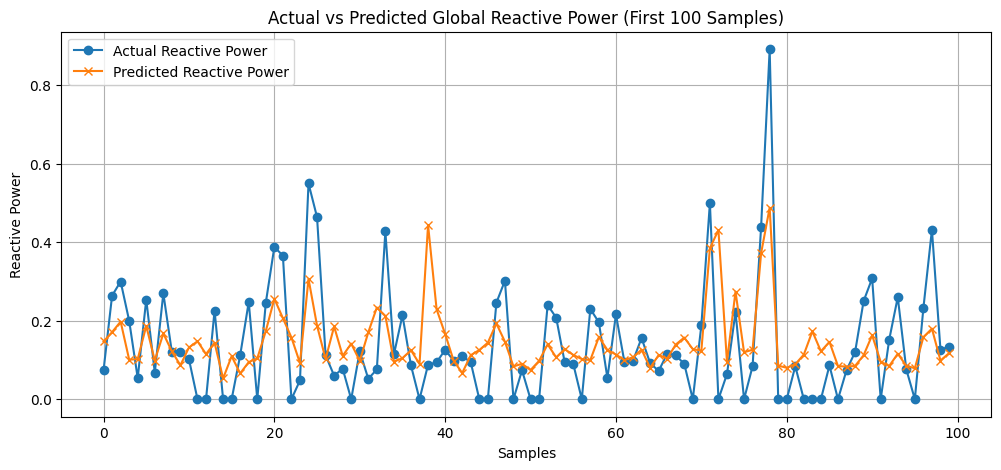

In [ ]:
# Create a figure with a specific size
plt.figure(figsize=(12,5))

# Plot the actual values from the test dataset_ real Global_reactive_power values
plt.plot(
    y_test.values[:100],
    label="Actual Reactive Power",
    marker='o')
# Plot the predicted values from the model_predicted by Linear Regression
plt.plot(
    y_pred[:100],
    label="Predicted Reactive Power",
    marker='x')
# Add title to explain the graph
plt.title("Actual vs Predicted Global Reactive Power (First 100 Samples)")
# Label the x-axis
plt.xlabel("Samples")
# Label the y-axis
plt.ylabel("Reactive Power")
# Show legend to distinguish between actual and predicted lines
plt.legend()
# Add grid
plt.grid(True)
# Display the plot
plt.show()

## Step 11: Train Models with  RandomForestRegressor and Evaluation



In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100, # Number of decision trees that will be created in the forest
    random_state=42,
    n_jobs=-1    # -1 means use all processors

)
# Train the Random Forest model using training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
# Use the trained Random Forest model to predict values for the test data
y_pred_rf = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
print("MAE:", mae_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE:", rmse_rf)

r2_rf = r2_score(y_test, y_pred_rf)
print("R2 Score:", r2_rf)

MAE: 0.020206248877654587
RMSE: 0.04005950999741533
R2 Score: 0.8735849905928049


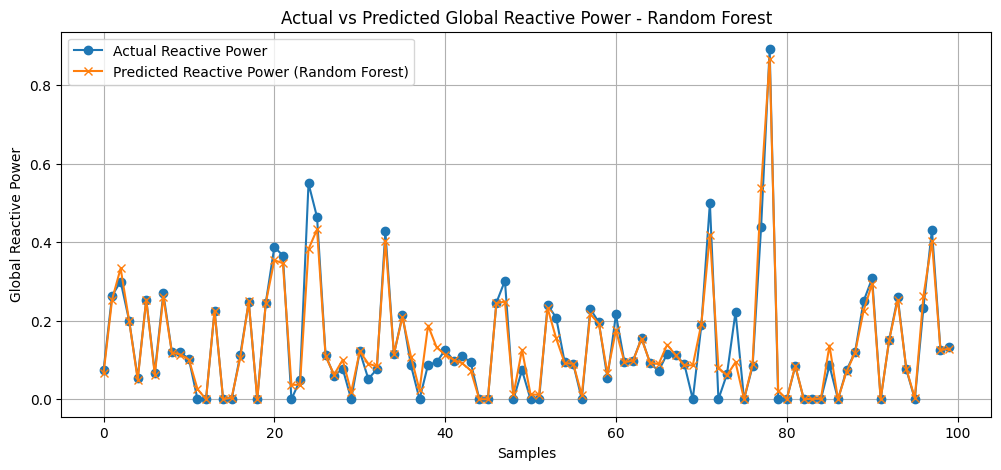

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label="Actual Reactive Power",
    marker='o'
)

plt.plot(
    y_pred_rf[:100],
    label="Predicted Reactive Power (Random Forest)",
    marker='x'
)

plt.title("Actual vs Predicted Global Reactive Power - Random Forest")
plt.xlabel("Samples")
plt.ylabel("Global Reactive Power")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
sample = X_test.iloc[[0]]#iloc[row_index, column_index]
prediction = rf_model.predict(sample)
# prediction[0] extracts the first prediction from the output array
print("Predicted:", prediction[0])
# We compare the prediction with the real value to check model accuracy
print("Actual:", y_test.iloc[0])

Predicted: 0.066
Actual: 0.074


In [ ]:
sample = X_test.iloc[[10]]
prediction = rf_model.predict(sample)
print("Predicted:", prediction[0])
# We compare the prediction with the real value to check model accuracy
print("Actual:", y_test.iloc[10])

Predicted: 0.10079999999999996
Actual: 0.102
